In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
data = pd.read_csv('../data/student_productivity_distraction_dataset_20000.csv')

data.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [4]:
data.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [5]:
data.shape

(20000, 18)

In [6]:
data.dropna( subset=['student_id'], inplace=True )

In [7]:
data.isna().sum()

student_id               0
age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
productivity_score       0
dtype: int64

<Axes: >

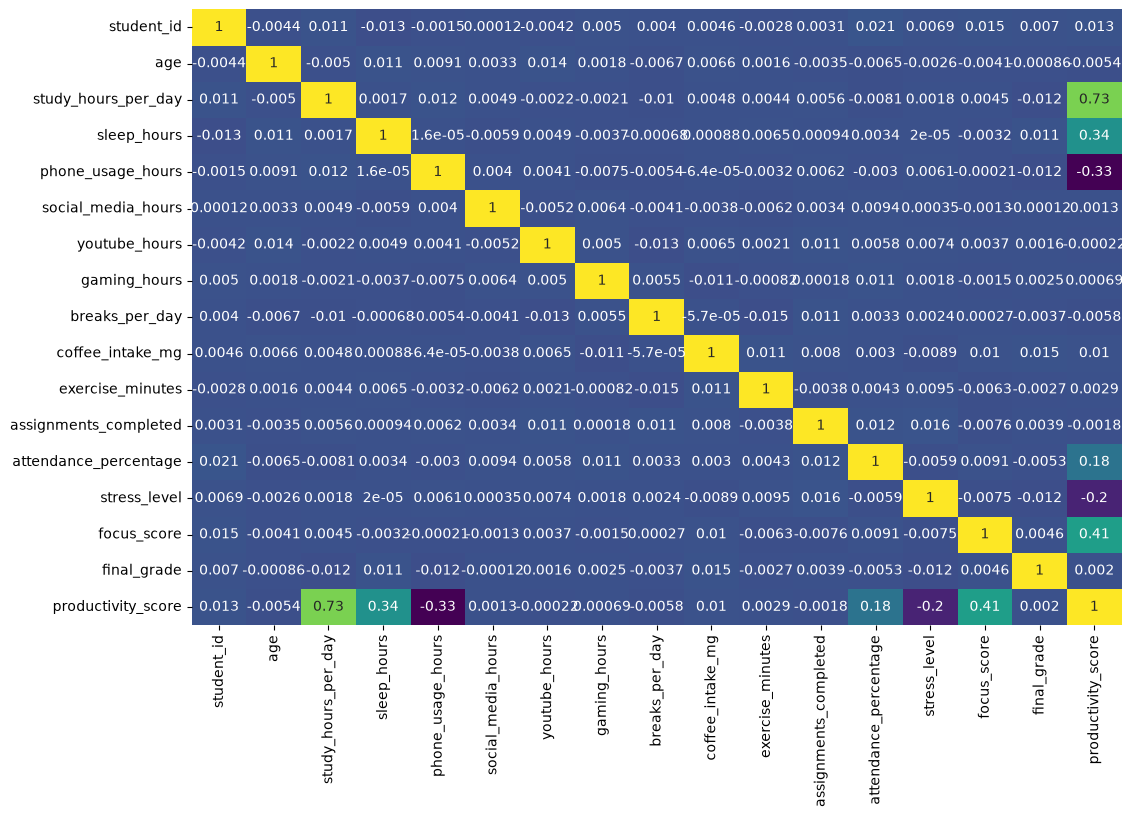

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cbar=False, cmap='viridis')


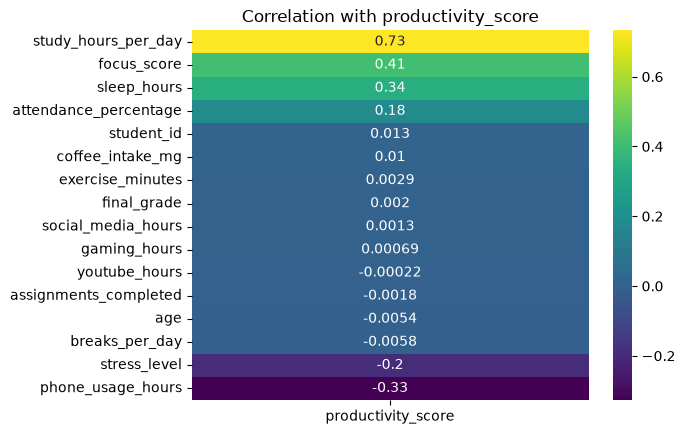

In [9]:
corr_matrix = data.select_dtypes(include=['number']).corr()
prod_corr = corr_matrix['productivity_score'].drop('productivity_score').sort_values(ascending=False)

sns.heatmap(prod_corr.to_frame(), annot=True, cmap='viridis', cbar=True)
plt.title('Correlation with productivity_score')
plt.xticks()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_7964\1913241439.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=data, x='focus_score', y='coffee_intake_mg' , palette='red')


<Axes: xlabel='focus_score', ylabel='coffee_intake_mg'>

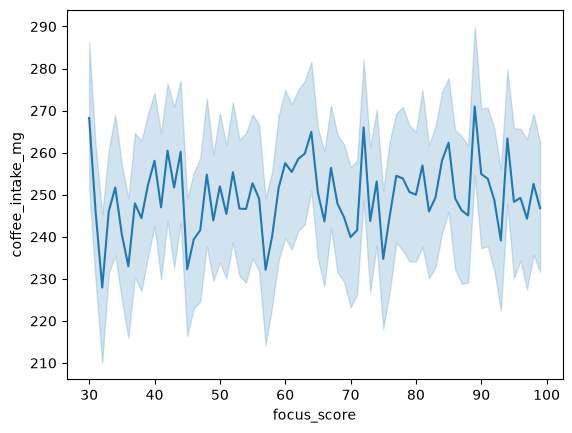

In [10]:
sns.lineplot(data=data, x='focus_score', y='coffee_intake_mg' , palette='red')

In [11]:
data['focus_score_sleep_ratio'] = data['focus_score'] / data['sleep_hours']

In [12]:
data['productivity_score'].describe()

count    20000.000000
mean        50.180419
std         16.086666
min          0.000000
25%         38.700000
50%         50.235000
75%         61.782500
max        100.000000
Name: productivity_score, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

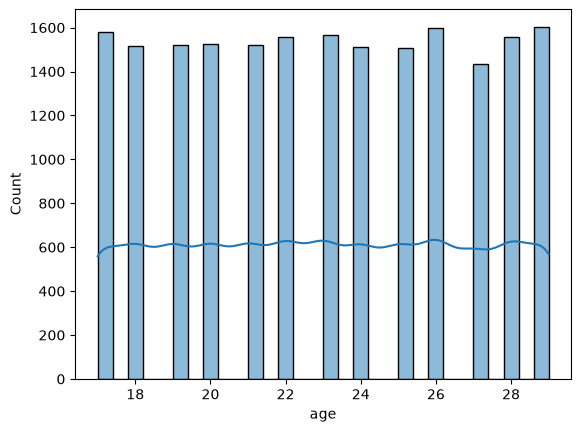

In [13]:
sns.histplot(data['age'], bins=30, kde=True)

<Axes: xlabel='gender', ylabel='productivity_score'>

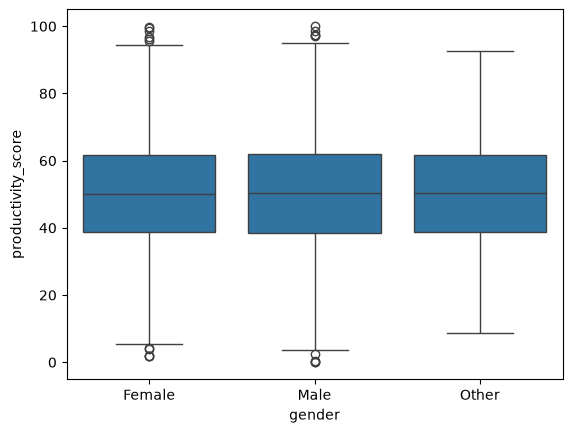

In [14]:
sns.boxplot(
    data=data,
    x="gender",
    y="productivity_score"
)

<Axes: xlabel='study_hours_per_day', ylabel='productivity_score'>

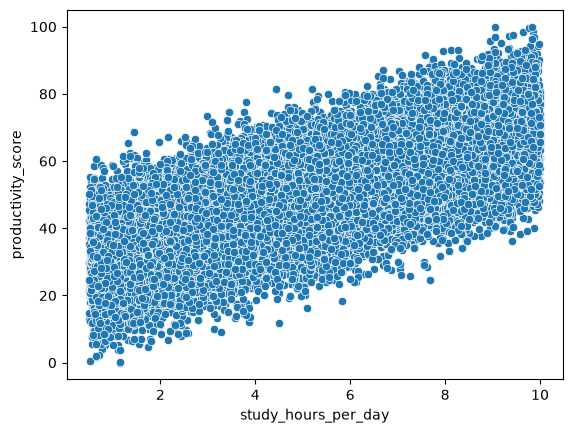

In [15]:
sns.scatterplot(
    data=data,
    x="study_hours_per_day",
    y="productivity_score"
)

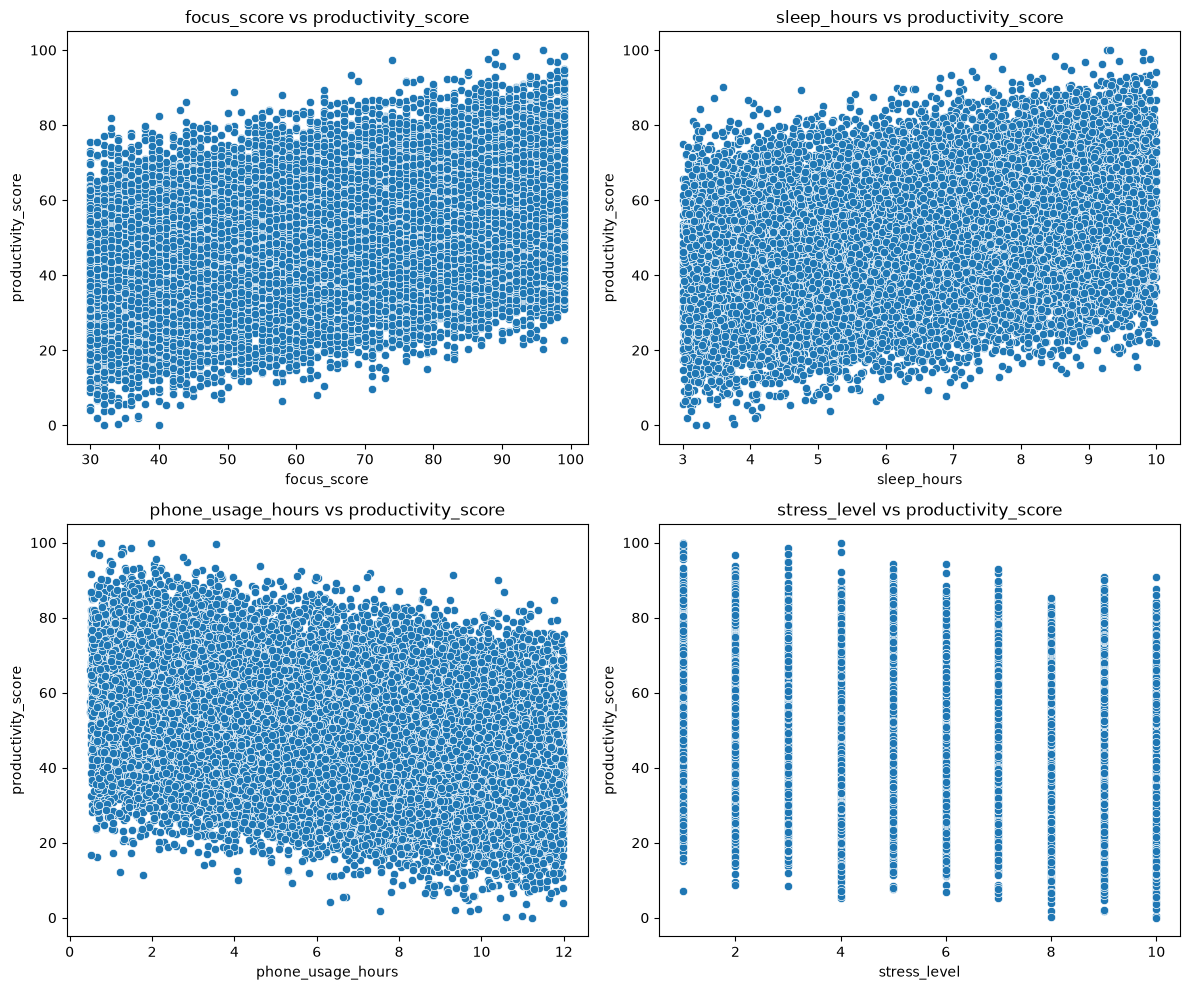

In [16]:
scatter_plt =[  'focus_score',
                'sleep_hours',
                'phone_usage_hours',
                'stress_level']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, col in enumerate(scatter_plt):
    sns.scatterplot(
        data=data,
        x=col,
        y="productivity_score",
        ax=axes[idx]
    )
    axes[idx].set_title(f'{col} vs productivity_score')

plt.tight_layout()
plt.show()

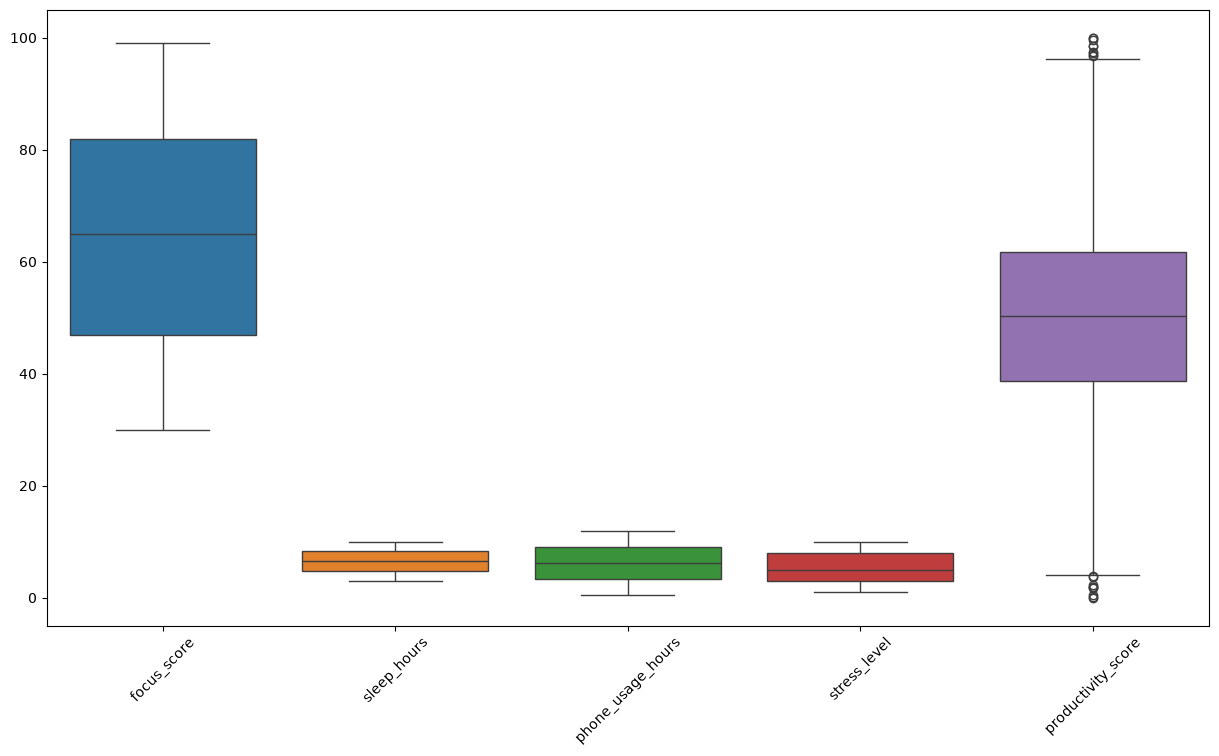

In [17]:
plt.figure(figsize=(15, 8))

sns.boxplot(
    data=data[scatter_plt + ['productivity_score']],
)

plt.xticks(rotation=45)
plt.show()

In [18]:
print(data["productivity_score"].describe())

print(data["productivity_score"].value_counts().sort_index(ascending=False))

count    20000.000000
mean        50.180419
std         16.086666
min          0.000000
25%         38.700000
50%         50.235000
75%         61.782500
max        100.000000
Name: productivity_score, dtype: float64
productivity_score
100.00    1
99.90     1
99.53     1
98.55     1
98.44     1
         ..
1.91      1
1.82      1
0.43      1
0.18      1
0.00      1
Name: count, Length: 6362, dtype: int64


In [19]:
from sklearn.linear_model import LinearRegression

features = [
    "study_hours_per_day",
    "focus_score",
    "sleep_hours",
    "attendance_percentage",
    "phone_usage_hours",
    "stress_level"
]

X = data[features]
y = data["productivity_score"]

model = LinearRegression()
model.fit(X, y)

print("R²:", model.score(X, y))
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

R²: 0.9999999681905607
Coefficients: [ 4.3163868   0.3237288   2.69774797  0.16186353 -1.61863663 -1.07909671]
Intercept: -6.2387546131950415


In [20]:
data[
    [
        "study_hours_per_day",
        "focus_score",
        "sleep_hours",
        "phone_usage_hours",
        "stress_level",
        "productivity_score"
    ]
].head(20)

,study_hours_per_day,focus_score,sleep_hours,phone_usage_hours,stress_level,productivity_score
0,4.35,57,3.63,3.38,10,33.78
1,6.14,49,6.58,5.48,10,48.99
2,4.98,38,3.26,4.83,2,36.60
3,3.19,50,4.58,10.06,6,19.87
4,7.67,41,6.21,3.02,6,52.90
5,7.18,70,3.52,4.02,10,47.31
6,9.06,35,6.36,11.45,8,41.23
7,6.37,59,4.86,3.31,6,53.81
8,4.19,39,4.87,9.66,3,25.99
9,7.28,73,9.56,2.13,10,73.18


In [21]:
print(data["productivity_score"].min())
print(data["productivity_score"].max())
print(data["productivity_score"].nunique())

0.0
100.0
6362


In [22]:
pred = model.predict(X)

comparison = pd.DataFrame({
    "actual": y,
    "predicted": pred,
    "difference": y - pred
})

print(comparison.head(20))
print(comparison["difference"].describe())

print(
    "Maximum absolute difference:",
    comparison["difference"].abs().max()
)

print(
    "Mean absolute difference:",
    comparison["difference"].abs().mean()
)

    actual  predicted  difference
0    33.78  33.781148   -0.001148
1    48.99  48.989942    0.000058
2    36.60  36.597059    0.002941
3    19.87  19.871672   -0.001672
4    52.90  52.900611   -0.000611
5    47.31  47.313572   -0.003572
6    41.23  41.230795   -0.000795
7    53.81  53.810791   -0.000791
8    25.99  25.986909    0.003091
9    73.18  73.180049   -0.000049
10   55.34  55.343714   -0.003714
11   77.35  77.353440   -0.003440
12   78.35  78.354867   -0.004867
13   76.03  76.030006   -0.000006
14   47.86  47.859096    0.000904
15   67.31  67.310862   -0.000862
16   59.99  59.990852   -0.000852
17   49.36  49.363372   -0.003372
18   42.69  42.694548   -0.004548
19   47.04  47.036289    0.003711
count    2.000000e+04
mean    -1.443598e-14
std      2.869089e-03
min     -5.085037e-03
25%     -2.474905e-03
50%     -1.724458e-05
75%      2.475188e-03
max      5.064514e-03
Name: difference, dtype: float64
Maximum absolute difference: 0.00508503663683868
Mean absolute difference: 0.

In [23]:
from sklearn.model_selection import train_test_split 

    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
mae = mean_absolute_error(y_test, xgb_pred)
r2 = r2_score(y_test, xgb_pred)

print("XGBoost RMSE:", rmse)
print("XGBoost MAE:", mae)
print("XGBoost R²:", r2)

XGBoost RMSE: 1.3889253580064742
XGBoost MAE: 1.096550970644951
XGBoost R²: 0.9925109399173108


In [25]:
print(data[features + ["productivity_score"]].corr()["productivity_score"].sort_values(ascending=False))

productivity_score       1.000000
study_hours_per_day      0.732777
focus_score              0.411366
sleep_hours              0.340902
attendance_percentage    0.176107
stress_level            -0.197128
phone_usage_hours       -0.326650
Name: productivity_score, dtype: float64


In [26]:
print(data[features + ["productivity_score"]].corr()["productivity_score"].sort_values(ascending=False))

productivity_score       1.000000
study_hours_per_day      0.732777
focus_score              0.411366
sleep_hours              0.340902
attendance_percentage    0.176107
stress_level            -0.197128
phone_usage_hours       -0.326650
Name: productivity_score, dtype: float64


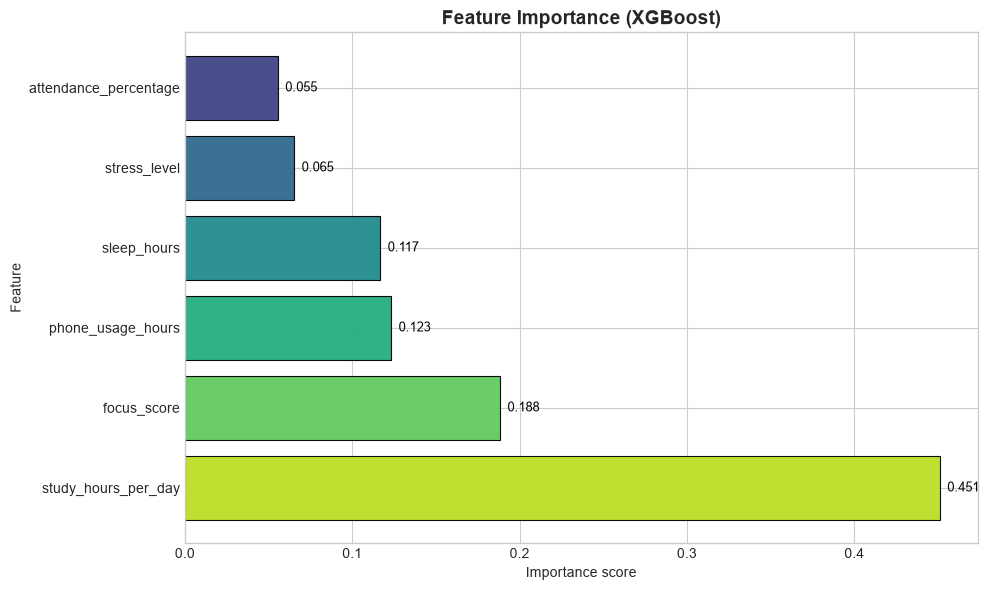

study_hours_per_day      0.451060
focus_score              0.188261
phone_usage_hours        0.123214
sleep_hours              0.116708
stress_level             0.065284
attendance_percentage    0.055473
dtype: float32


In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

importance = pd.Series(xgb.feature_importances_, index=features)
importance = importance.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(importance)))

bars = ax.barh(
    importance.index,
    importance.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.95
)

ax.invert_yaxis()
ax.set_title('Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance score')
ax.set_ylabel('Feature')

for bar, value in zip(bars, importance.values):
    ax.text(
        value + (importance.max() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        f'{value:.3f}',
        va='center',
        fontsize=9,
        color='black'
    )

plt.tight_layout()
plt.show()

print(importance.sort_values(ascending=False))


In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rmse_rf = mean_squared_error(y_test, rf_pred) ** 0.5
mae_rf = mean_absolute_error(y_test, rf_pred)   
score_rf = r2_score(y_test, rf_pred) 

print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)
print("Random Forest R²:", score_rf)

Random Forest RMSE: 2.1321994498979215
Random Forest MAE: 1.6747288
Random Forest R²: 0.9823507947097633


In [29]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rmse_rf = mean_squared_error(y_test, rf_pred) ** 0.5
mae_rf = mean_absolute_error(y_test, rf_pred)
score_rf = r2_score(y_test, rf_pred)

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

rmse_xgb = mean_squared_error(y_test, xgb_pred) ** 0.5
mae_xgb = mean_absolute_error(y_test, xgb_pred)
r2_xgb = r2_score(y_test, xgb_pred)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [lr_rmse, rmse_rf, rmse_xgb],
    "MAE": [lr_mae, mae_rf, mae_xgb],
    "R²": [lr_r2, score_rf, r2_xgb]
}).sort_values("R²", ascending=False)

results = results.round({"RMSE": 4, "MAE": 4, "R²": 4})
results

,Model,RMSE,MAE,R²
0,Linear Regression,0.0029,0.0025,1.0000
2,XGBoost,1.3889,1.0966,0.9925
1,Random Forest,2.1322,1.6747,0.9824


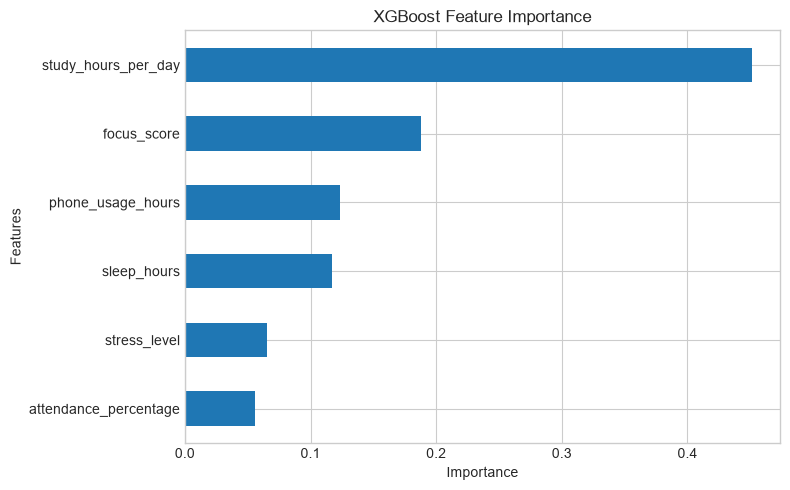

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# Get XGBoost feature importance
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

# Plot
plt.figure(figsize=(8, 5))

importance.plot(kind="barh")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()

plt.show()

In [31]:
print(data[features + ["productivity_score"]].head(20))

    study_hours_per_day  focus_score  ...  stress_level  productivity_score
0                  4.35           57  ...            10               33.78
1                  6.14           49  ...            10               48.99
2                  4.98           38  ...             2               36.60
3                  3.19           50  ...             6               19.87
4                  7.67           41  ...             6               52.90
5                  7.18           70  ...            10               47.31
6                  9.06           35  ...             8               41.23
7                  6.37           59  ...             6               53.81
8                  4.19           39  ...             3               25.99
9                  7.28           73  ...            10               73.18
10                 6.38           82  ...            10               55.34
11                 6.36           92  ...            10               77.35
12          

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("RMSE:", mean_squared_error(y_test, lr_pred) ** 0.5)
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("R²:", r2_score(y_test, lr_pred))

print("\nCoefficients:")
for feature, coefficient in zip(X_train.columns, lr.coef_):
    print(f"{feature}: {coefficient:.6f}")

print("\nIntercept:", lr.intercept_)

RMSE: 0.002873962446738119
MAE: 0.0024842482840402636
R²: 0.9999999679349679

Coefficients:
study_hours_per_day: 4.316386
focus_score: 0.323729
sleep_hours: 2.697744
attendance_percentage: 0.161863
phone_usage_hours: -1.618633
stress_level: -1.079092

Intercept: -6.238752590363319


In [33]:
print("Duplicate rows:", data.duplicated().sum())

print(
    "Duplicate feature combinations:",
    data.duplicated(subset=features).sum()
)

Duplicate rows: 0
Duplicate feature combinations: 0
